# Chapter 10.2 — Evaluating a Classifier

*Course 888102 · International College of Digital Innovation, Chiang Mai University*

Part 10.1 grew a decision tree from fourteen golf days and read it as five rules; it scored 100% on the days it was grown from. This part asks how good the tree really is. It applies the Chapter 9 toolkit — predicted against actual, the four boxes of the confusion matrix, accuracy, precision, recall and F₁ — to that tree, on days it has **not** seen, and then repeats the test many times with cross-validation. The same evaluation is then applied to a real dataset — 569 breast-cancer tumors — with scikit-learn, and the homework asks questions of that dataset.

**In this chapter:** Predicted against actual · Held-out days · The four boxes · Accuracy, precision, recall, F₁ · Cross-validation · The breast-cancer tumors · scikit-learn · Homework



> **Learning objectives.** By the end of this part you should be able to:
>
> - **Compare predicted with actual** — lay a model's answers beside what really happened, and place every case in one of four boxes.
> - **Read the four metrics** — accuracy, precision, recall and F₁ as ratios of the boxes, and which mistake each one sees.
> - **Test on unseen data** — say why the score on the training rows is only how well the model fits, and measure how well it predicts.
> - **Check for consistency** — run the test many times with cross-validation and read whether the scores agree.



**Contents**

- **10.2.1 · The tree from Part 10.1** — the model under test, rebuilt in one cell
- **10.2.2 · The confusion matrix** — recap from Chapter 9: the four boxes and the four metrics
- **10.2.3 · Testing on days the tree has not seen** — the four boxes, from the library
- **10.2.4 · Cross-validation** — testing the model many times
- **10.2.5 · A real dataset — the breast-cancer tumors** — the same evaluation with scikit-learn
- **10.2.6 · Glossary** — the terms of this part
- **10.2.7 · Homework** — the graded work, on the tumors



> **How to use this notebook.** Each idea is explained first, then built in code one step per cell: the text above a code cell says what the step does and why it comes next, and its **Interpretation** says what the output will show. Run the cells in order — later cells use variables made by earlier ones. The graded work is Section 10.2.7.

> **Continuing from Chapter 9 and Part 10.1.** Chapter 9 taught the confusion matrix, its four metrics and cross-validation in full (Sections 9.3.4 and 9.3.5), on a screening example of 1,000 people. They are recapped here in one place each, with Chapter 9's own numbers, and then applied to this chapter's model. Part 10.1 grew the tree; its functions are rebuilt in one cell in Section 10.2.1.



#### Setting up

One cell of preparation: numpy for arrays of numbers, pandas for tables, matplotlib for charts. Section 10.2.6 adds scikit-learn, which scores a model in one line.



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 100
print("numpy", np.__version__, "· pandas", pd.__version__, "· ready")

numpy 2.4.6 · pandas 3.0.5 · ready


## 10.2.1 · The tree from Part 10.1

*the model under test*

> **Recap from Part 10.1.** Fourteen golf days, each with four features — outlook, temperature, humidity, wind — and the answer: whether golf was played. Nine Yes, five No. Part 10.1 grew a tree from them with scikit-learn, in one line, and it was right on all fourteen days it was grown from. That is how well it fits. This part measures how well it predicts.



#### The steps

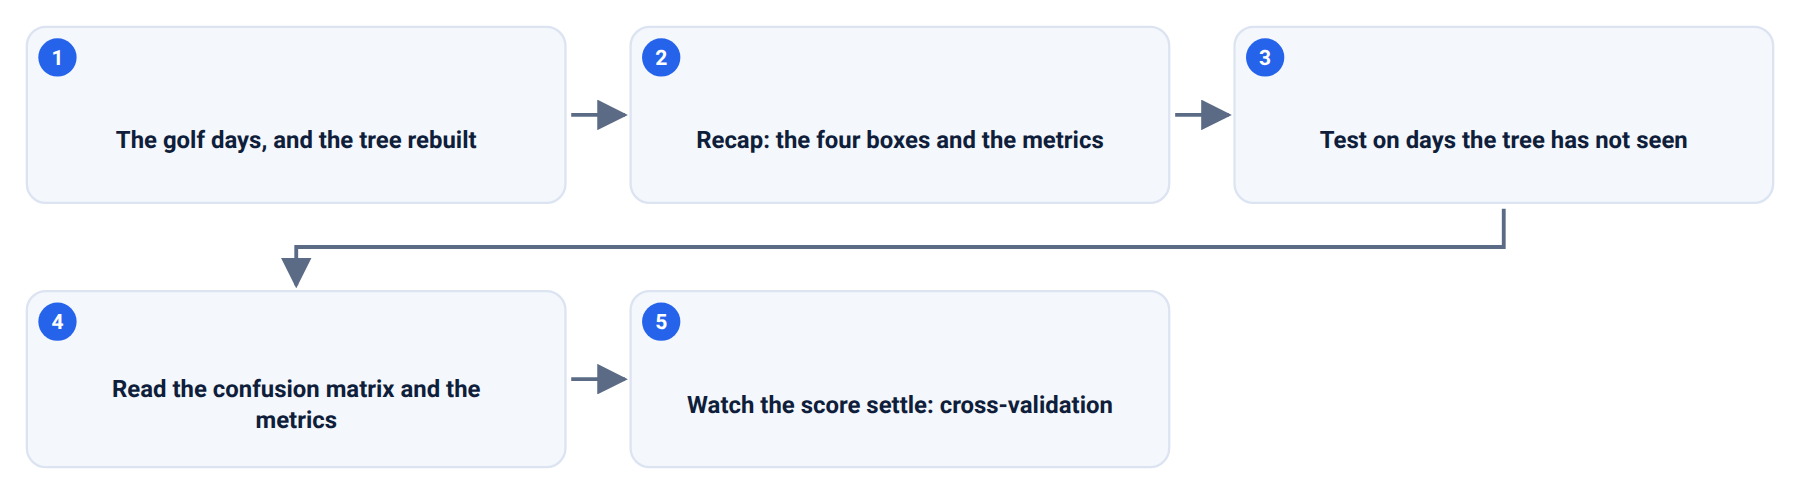

*What the cells of Sections 10.2.1 to 10.2.4 do.*



#### The golf days

The fourteen days of Part 10.1, in the same table, so this notebook stands on its own.



In [2]:
golf = pd.DataFrame({
    "outlook":  ["Rainy", "Rainy", "Overcast", "Sunny", "Sunny", "Sunny", "Overcast",
                 "Rainy", "Rainy", "Sunny", "Rainy", "Overcast", "Overcast", "Sunny"],
    "temp":     ["Hot", "Hot", "Hot", "Mild", "Cool", "Cool", "Cool",
                 "Mild", "Cool", "Mild", "Mild", "Mild", "Hot", "Mild"],
    "humidity": ["High", "High", "High", "High", "Normal", "Normal", "Normal",
                 "High", "Normal", "Normal", "Normal", "High", "Normal", "High"],
    "windy":    ["No", "Yes", "No", "No", "No", "Yes", "Yes",
                 "No", "No", "No", "Yes", "Yes", "No", "Yes"],
    "play":     ["No", "No", "Yes", "Yes", "Yes", "No", "Yes",
                 "No", "Yes", "Yes", "Yes", "Yes", "Yes", "No"],
})
golf.index = range(1, 15)
FEATURES = ["outlook", "temp", "humidity", "windy"]
golf

,outlook,temp,humidity,windy,play
1,Rainy,Hot,High,No,No
2,Rainy,Hot,High,Yes,No
3,Overcast,Hot,High,No,Yes
4,Sunny,Mild,High,No,Yes
5,Sunny,Cool,Normal,No,Yes
6,Sunny,Cool,Normal,Yes,No
7,Overcast,Cool,Normal,Yes,Yes
8,Rainy,Mild,High,No,No
9,Rainy,Cool,Normal,No,Yes
10,Sunny,Mild,Normal,No,Yes


#### The tree, rebuilt

The four columns of words are coded as numbers and the tree is grown in one line, exactly as in Part 10.1. `.score()` checks it on the days it was grown from.



> **Interpretation.** 100% — the number Part 10.1 ended on. Every question in this part is about whether that number means anything.



In [3]:
from sklearn.tree import DecisionTreeClassifier

codes = golf[FEATURES].apply(lambda col: col.astype("category").cat.codes)
model = DecisionTreeClassifier(random_state=0).fit(codes, golf["play"])
print(f"on its own 14 days: {model.score(codes, golf['play']):.0%}")

on its own 14 days: 100%


## 10.2.2 · The confusion matrix

*recap from Chapter 9*

Evaluating a classifier starts with one comparison per case: what the model predicted beside what actually happened. Every case then lands in exactly one of four boxes, and the four counts are the **confusion matrix**. In a binary problem one class is the positive class — here Yes, the days golf was played — and the boxes are named from its point of view.

|  | actually Yes | actually No |
|---|---|---|
| **predicted Yes** | **TP** — true positive, a correct catch | **FP** — false positive, a Type I error |
| **predicted No** | **FN** — false negative, a Type II error | **TN** — true negative, a correct pass |

> **Recap from Chapter 9.** Section 9.3.5 worked this on 1,000 screened people, 60 of them ill, 50 flagged, 40 of those correctly: TP 40, FP 10, FN 20, TN 930. Accuracy $970/1000 = 97.0\%$ — and 94% for a model that flags nobody. Precision $40/50 = 80.0\%$: of those flagged, the share really ill. Recall $40/60 = 66.7\%$: of the ill, the share caught. $F_1 = 72.7\%$. Accuracy is nearly blind to a rare class; precision and recall see the two mistakes separately.

$$\text{Accuracy} = \frac{TP + TN}{n} \qquad \text{Precision} = \frac{TP}{TP + FP} \qquad \text{Recall} = \frac{TP}{TP + FN} \qquad F_1 = \frac{2\,PR}{P + R}$$

*Every metric, as a ratio of the four boxes.* $n$ is every case in the table. Precision divides by the row the model chose, recall by the column the truth chose; $F_1$ balances the two — it is high only when both are.



#### The four boxes of the Chapter 9 example

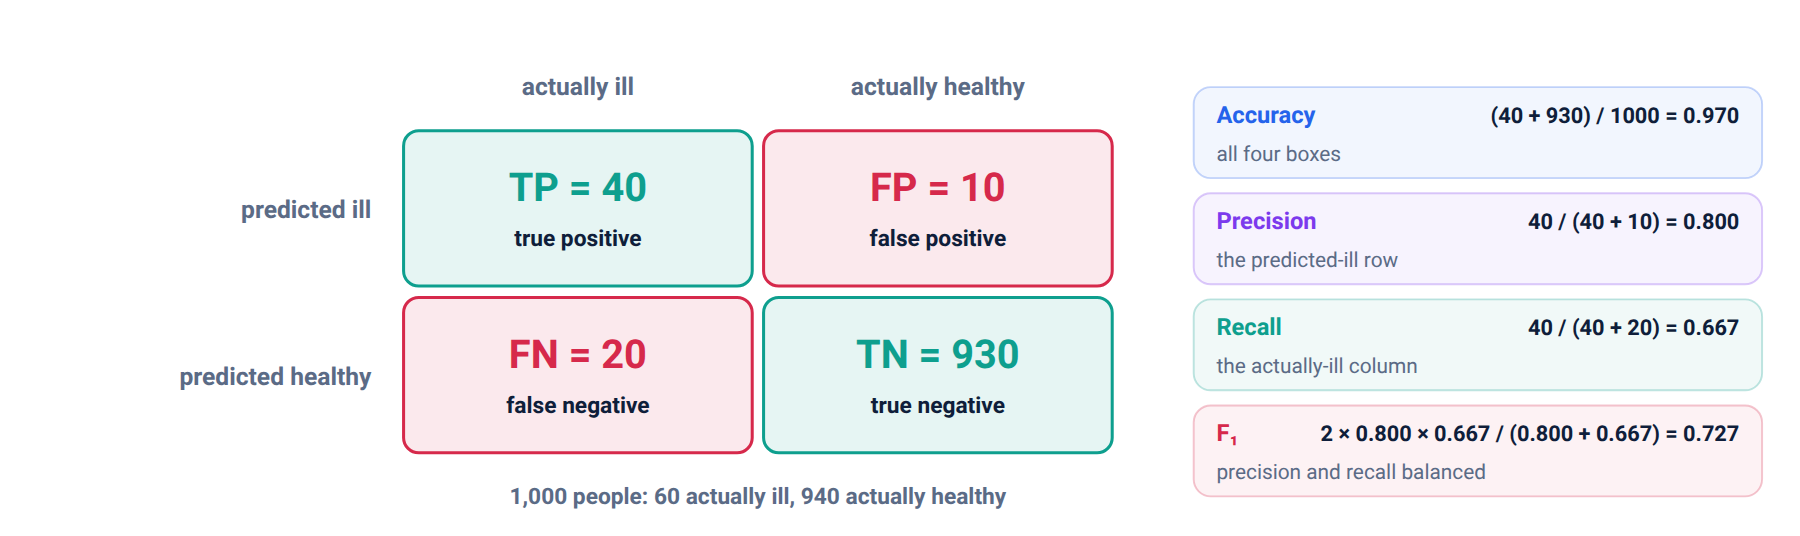

*The Chapter 9 screening example. The large TN box makes accuracy high; precision and recall read the two mistakes separately.*



## 10.2.3 · Testing on days the tree has not seen

*the four boxes, from the library*

A tree grown on all fourteen days has already seen every day it is asked about, so its 100% says nothing about tomorrow. The honest test holds a day back: grow the tree on the other thirteen, ask it about the held-out day, and write its answer beside what really happened. Fourteen days give fourteen such tests, and the library runs all of them in one line.



#### The fourteen tests in one line

`LeaveOneOut()` holds out one row at a time and `cross_val_predict` collects the prediction made for each held-out row, so every answer comes from a tree that never saw that day.



> **Interpretation.** Fourteen rows, each one a test. Ten agree; days 4, 6, 11 and 14 do not — the tree said the opposite of what happened on those four.



In [4]:
from sklearn.model_selection import cross_val_predict, LeaveOneOut
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

held_out = cross_val_predict(DecisionTreeClassifier(random_state=0), codes, golf["play"], cv=LeaveOneOut())
comparison = pd.DataFrame({"actual": golf["play"], "predicted": held_out}, index=golf.index)
comparison

,actual,predicted
1,No,No
2,No,No
3,Yes,Yes
4,Yes,No
5,Yes,Yes
6,No,Yes
7,Yes,Yes
8,No,No
9,Yes,Yes
10,Yes,Yes


#### The score on held-out days

`accuracy_score` counts the rows that agree and divides by fourteen.



> **Interpretation.** 0.714 — right on 10 of 14 days it had not seen, against 100% on the days it was grown from. The first number says how well the tree fits; only this one says how well it predicts.



In [5]:
print(f"right on {(held_out == golf['play']).sum()} of 14: {accuracy_score(golf['play'], held_out):.3f}")

right on 10 of 14: 0.714


#### The four boxes

`confusion_matrix` counts the four boxes from the same fourteen comparisons. One difference matters: scikit-learn puts the **actual** classes down the rows and the predicted across the columns, the transpose of the table above. `labels=` fixes the order, so the top-left cell is actual No predicted No.



> **Interpretation.** Reading it with No first: TN 3, FP 2, FN 2, TP 7. Of the nine days golf was played the tree caught seven and missed two; of the five days it was not, the tree passed three and raised two false alarms.



In [6]:
confusion_matrix(golf["play"], held_out, labels=["No", "Yes"])

array([[3, 2],
       [2, 7]])

#### The tree's four boxes

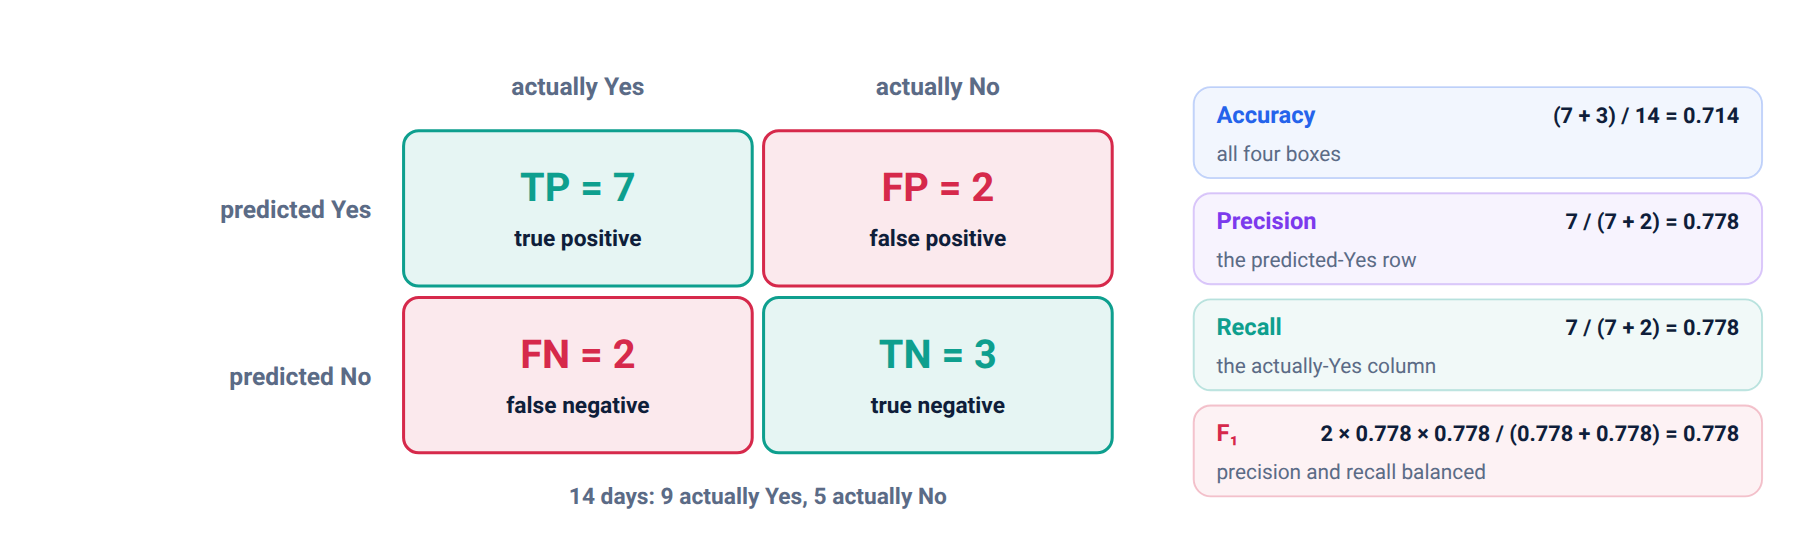

*The fourteen held-out comparisons counted into the four boxes, with Yes as the positive class.*



#### Precision, recall and F₁ by name

`classification_report` prints the three metrics for each class, with **support** — how many days of that class there were. The row for Yes reads the metrics from the positive class's point of view, the way the formulas above define them.



> **Interpretation.** The Yes row:
>
> - **Precision 0.778** — of the 9 days the tree said Yes, 7 were really played.
> - **Recall 0.778** — of the 9 days golf was played, the tree caught 7.
> - **F₁ 0.778** — precision and recall balanced in one number.
> - **Accuracy 0.714** — right on 10 of the 14 days altogether.



In [7]:
print(classification_report(golf["play"], held_out, digits=3))

              precision    recall  f1-score   support

          No      0.600     0.600     0.600         5
         Yes      0.778     0.778     0.778         9

    accuracy                          0.714        14
   macro avg      0.689     0.689     0.689        14
weighted avg      0.714     0.714     0.714        14



#### Held-out numbers, not training numbers

> **Watch out.** On its own 14 days the tree scored 100%. Asked about days it had not seen, it is right 10 times in 14. Only the held-out numbers say how the tree will do on tomorrow's weather, and only they are worth reporting. Fourteen days is also a very small test: one day moved changes the score by about seven points, so a number from fourteen tests carries a wide margin of its own.



## 10.2.4 · Cross-validation

*testing the model many times*

One test on one held-out day can be lucky or unlucky. **Cross-validation** repeats the test many times, each time on rows the model has not seen, and looks at whether the scores agree. The fourteen tests just run are exactly that, and watching the score settle as they accumulate shows what one test alone cannot.

> **Recap from Chapter 9.** Section 9.3.4 introduced cross-validation as $k$-fold: cut the rows into $k$ folds, hold out each fold in turn, and average the $k$ scores. Holding out one row at a time, as here, is the case $k = n$; with hundreds of rows five folds are the usual choice, and Section 10.2.5 uses them.



#### The score after each test

A test is right when the held-out prediction equals the actual answer. `cumsum()` adds the rights up test by test, and dividing by the number of tests so far gives the score after each one — a running accuracy that starts with a single test and ends with all fourteen. The chart in the next cell draws this accuracy so far against the number of held-out tests run.



> **Interpretation.** The running score after each held-out day.
>
> - **Tests 1 to 3 — 1.000.** A single test can only say 0% or 100%; three right in a row keep it at 1.
> - **Test 4 — 0.750.** Day 4 is missed and one wrong in four pulls the score down at once.
> - **Tests 5 to 13 — between 0.67 and 0.80**, moving less with every test added.
> - **Test 14 — 0.714**, the 10 of 14 the confusion matrix counted.



In [8]:
right = (comparison["actual"] == comparison["predicted"]).astype(int)
running = pd.DataFrame({
    "right": right,
    "tests so far": np.arange(1, 15),
    "score so far": (right.cumsum() / np.arange(1, 15)).round(3),
}, index=golf.index)
running

,right,tests so far,score so far
1,1,1,1.000
2,1,2,1.000
3,1,3,1.000
4,0,4,0.750
5,1,5,0.800
6,0,6,0.667
7,1,7,0.714
8,1,8,0.750
9,1,9,0.778
10,1,10,0.800


#### The score settling

The running score as a line, with the training score of 100% drawn for comparison. Each point is one more held-out test.



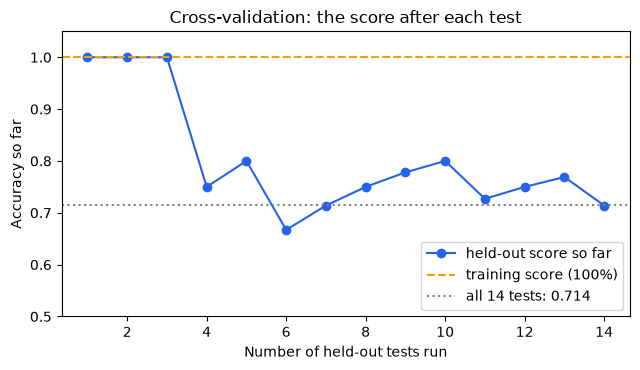

In [9]:
plt.figure(figsize=(6.5, 3.8))
plt.plot(running["tests so far"], running["score so far"], marker="o", color="#2563EB", label="held-out score so far")
plt.axhline(1.0, color="#F59E0B", linestyle="--", label="training score (100%)")
plt.axhline(10 / 14, color="gray", linestyle=":", label="all 14 tests: 0.714")
plt.ylim(0.5, 1.05)
plt.xlabel("Number of held-out tests run")
plt.ylabel("Accuracy so far")
plt.title("Cross-validation: the score after each test")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

#### What the chart shows

> **Interpretation.** What the chart shows:
>
> - **The blue line** — the held-out score after each test — swings widely at first and settles as tests accumulate. Any single test would have said 0% or 100%.
> - **The dashed line at 100%** is the training score. The gap between it and the settled 0.714 is the difference between fitting the days and predicting them.
> - **Only the settled score is worth reporting.** Cross-validation exists to reach it: many tests, each on unseen rows, averaged.



#### Where Sections 10.2.1 to 10.2.4 leave us

> **Key idea.** The tree of Part 10.1 has been judged honestly: 10 of 14 held-out days, precision 0.778, recall 0.778, and a score that settles at 0.714 as the tests accumulate — against the 100% that fitting alone produced. The rest of this part applies the same evaluation to a real dataset, where the numbers rest on hundreds of rows instead of fourteen.



## 10.2.5 · A real dataset — the breast-cancer tumors

*the same evaluation with scikit-learn*

The dataset is the Wisconsin breast-cancer data, bundled with scikit-learn: 569 tumors, each described by 30 measurements taken from a digitized image of a biopsy — the size, texture and shape of the cell nuclei — and each labeled by what the biopsy found: **malignant** (cancer) or **benign** (not cancer). Two classes, so this is a binary problem, and the positive class — the one being looked for — is malignant.

> **The question.** From the 30 measurements of a tumor, how well can a decision tree tell malignant from benign — and which mistake does it make more often: calling a benign tumor malignant, or a malignant one benign?

> **The split.** With 569 rows the train/test split is made once, as in Chapter 9: 70% of the tumors train the tree and 30% are held back to test it. `train_test_split` does the splitting; `stratify=` keeps the share of malignant tumors the same in both parts, and the seed 888102 makes every student's split identical. The tree is grown three questions deep, so that it does not simply memorize the training rows.



#### The steps

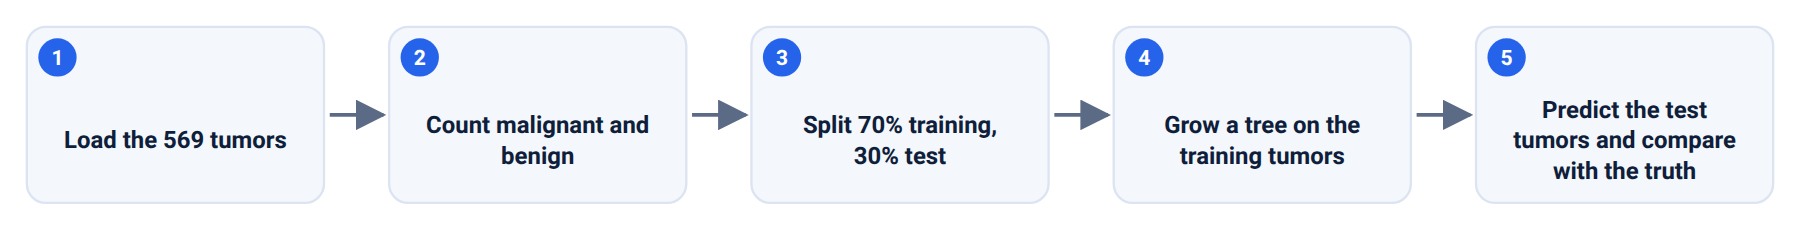

*The tumor walk. The homework in Section 10.2.7 counts the boxes, reads the metrics and cross-validates.*



#### Loading the tumors

`load_breast_cancer(as_frame=True)` returns the 30 measurements as a table and the diagnosis as a number, 0 for malignant and 1 for benign. The cell replaces the numbers with the two words, so that every later output reads as a diagnosis rather than a code, and shows the first rows of a few columns.



> **Interpretation.** 569 rows and 31 columns: 30 measurements and the diagnosis. The measurements are sizes and shapes of the cell nuclei — a radius in pixels, a texture, how concave the outline is — each given as a mean, a standard error and a worst value across the nuclei in the image.



In [10]:
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer(as_frame=True)
tumors = cancer.data.copy()
tumors["diagnosis"] = np.where(cancer.target == 0, "malignant", "benign")    # 0 = malignant in the file
print("shape:", tumors.shape)
tumors[["mean radius", "mean texture", "mean concavity", "worst radius", "diagnosis"]].head()

shape: (569, 31)


,mean radius,mean texture,mean concavity,worst radius,diagnosis
0,17.99,10.38,0.3001,25.38,malignant
1,20.57,17.77,0.0869,24.99,malignant
2,19.69,21.25,0.1974,23.57,malignant
3,11.42,20.38,0.2414,14.91,malignant
4,20.29,14.34,0.1980,22.54,malignant


#### Malignant and benign

The count of each class, before anything is predicted. It says how mixed the whole table is and what a model that always answered benign would score.



> **Interpretation.** 212 malignant and 357 benign. A model that called every tumor benign would be 63% accurate and would miss every cancer — the reason accuracy alone is not enough here, and precision and recall are needed.



In [11]:
tumors["diagnosis"].value_counts()

diagnosis
benign       357
malignant    212
Name: count, dtype: int64

#### The split

`train_test_split` shuffles the rows with the seed and cuts them 70/30; `stratify=y` keeps the malignant share the same in both parts. Four objects come back: the training features and labels, and the test features and labels. The cell prints the sizes and the malignant count in each part.



> **Interpretation.** 398 tumors to learn from and 171 held back, with the same share of malignant tumors in each. The 171 test tumors have their diagnoses hidden from the tree until the comparison.



In [12]:
from sklearn.model_selection import train_test_split

X = tumors.drop(columns="diagnosis")
y = tumors["diagnosis"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=888102, stratify=y)
print("training tumors:", len(X_train), "  of which malignant:", (y_train == "malignant").sum())
print("test tumors:    ", len(X_test), "  of which malignant:", (y_test == "malignant").sum())

training tumors: 398   of which malignant: 148
test tumors:     171   of which malignant: 64


#### Growing the tree on the training tumors

`DecisionTreeClassifier(max_depth=3)` grows a tree three questions deep on the training rows only; `export_text` prints it, and `.score(X_train, y_train)` is its training accuracy — how well it fits the rows it has seen.



> **Interpretation.** The root asks how concave the outline of the nuclei is (mean concave points): a smoother outline goes left, toward benign, and a more indented one right, where the size of the nuclei (worst area) decides. Three questions deep, eight leaves. The training accuracy is high, as it always is on the rows a tree was grown from; it is not the number that matters.



In [13]:
from sklearn.tree import DecisionTreeClassifier, export_text

model = DecisionTreeClassifier(max_depth=3, random_state=0).fit(X_train, y_train)
print(export_text(model, feature_names=list(X.columns), class_names=list(model.classes_)))
print(f"training accuracy: {model.score(X_train, y_train):.1%}")

|--- mean concave points <= 0.05
|   |--- worst area <= 929.80
|   |   |--- worst smoothness <= 0.18
|   |   |   |--- class: benign
|   |   |--- worst smoothness >  0.18
|   |   |   |--- class: benign
|   |--- worst area >  929.80
|   |   |--- mean texture <= 18.68
|   |   |   |--- class: benign
|   |   |--- mean texture >  18.68
|   |   |   |--- class: malignant
|--- mean concave points >  0.05
|   |--- worst area <= 785.80
|   |   |--- worst symmetry <= 0.33
|   |   |   |--- class: benign
|   |   |--- worst symmetry >  0.33
|   |   |   |--- class: malignant
|   |--- worst area >  785.80
|   |   |--- worst concavity <= 0.22
|   |   |   |--- class: benign
|   |   |--- worst concavity >  0.22
|   |   |   |--- class: malignant

training accuracy: 98.5%


#### Predicting the test tumors

`.predict(X_test)` gives the tree's diagnosis of each held-back tumor from its measurements alone. Beside the true diagnosis, this is the same table as Section 10.2.3, with malignant as the positive class. The first ten rows are shown; the homework counts the boxes of all 171.



> **Interpretation.** One row per test tumor, each in one of the four boxes. The test accuracy is lower than the training accuracy — the tree fits the tumors it saw better than it predicts the ones it did not — and the four boxes, counted in the homework, say which mistake it makes more often.



In [14]:
predicted_test = model.predict(X_test)
test_comparison = pd.DataFrame({
    "actual": y_test.values,
    "predicted": predicted_test,
}, index=X_test.index)
print("test accuracy:", round(accuracy_score(y_test, predicted_test), 3))
test_comparison.head(10)

test accuracy: 0.912


,actual,predicted
262,malignant,malignant
384,benign,benign
289,benign,benign
449,malignant,malignant
81,benign,malignant
78,malignant,malignant
65,malignant,malignant
435,malignant,malignant
23,malignant,malignant
536,malignant,benign


#### From here

> **Key idea.** The golf tree and the tumor tree are evaluated the same way: hidden answers, a prediction for each, and the pairs counted into four boxes. The homework below counts them for the 171 test tumors, reads the four metrics, decides which mistake matters more for a patient, and repeats the test with five-fold cross-validation. Part 10.3 turns from categories to numbers: a line that predicts the price of a house, fitted, read and judged in the same steps.



## 10.2.6 · Glossary

*the terms of this part*

| Term | Meaning |
|---|---|
| **Held-out row** | A row hidden from the model while it learns, then used to test it. |
| **Confusion matrix** | The four counts of predicted against actual: TP, FP, FN, TN. |
| **True positive / true negative** | A positive case predicted positive / a negative case predicted negative. |
| **False positive (Type I error)** | A negative case predicted positive — a false alarm. |
| **False negative (Type II error)** | A positive case predicted negative — a miss. |
| **Accuracy** | (TP + TN) / n — the share of all cases predicted right. |
| **Precision** | TP / (TP + FP) — of the cases predicted positive, the share really positive. |
| **Recall** | TP / (TP + FN) — of the really positive cases, the share caught. |
| **F₁** | The harmonic mean of precision and recall; high only when both are. |
| **Training accuracy / test accuracy** | The score on the rows the model learned from / on rows it never saw. Only the second says how it predicts. |
| **Cross-validation** | Repeating the held-out test many times — one row or one fold at a time — and looking at whether the scores agree. |
| **Stratified split** | A train/test split that keeps each class's share the same in both parts. |



## 10.2.7 · Homework

*the graded work, on the tumors*

The exercises continue Section 10.2.5 on the breast-cancer tumors, in the order this part taught the ideas: count the boxes, read the metrics, weigh the two mistakes, cross-validate, and compare fitting with predicting. Each exercise has a code cell for your work and a text cell for your answer.

**Student information** — double-click this cell to edit it and fill in your details.

**Name:** ____________________________

**Student ID:** ______________________

**Date:** ____________________________



#### The homework dataset — the tumors, split and predicted

*run this cell, but do not modify it*

Run this cell once and do not edit it. It rebuilds Section 10.2.5 — the 569 tumors, the 70/30 split with seed 888102, the depth-3 tree — and leaves you `test_comparison`, the 171 test tumors with actual and predicted diagnosis, plus `X`, `y`, the split parts and `model`. scikit-learn's `confusion_matrix` and `classification_report` are imported for you.



In [15]:
# ------- RUN THIS CELL, BUT DO NOT MODIFY IT -------
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.metrics import confusion_matrix, classification_report

cancer = load_breast_cancer(as_frame=True)
tumors = cancer.data.copy()
tumors["diagnosis"] = np.where(cancer.target == 0, "malignant", "benign")
X = tumors.drop(columns="diagnosis")
y = tumors["diagnosis"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=888102, stratify=y)
model = DecisionTreeClassifier(max_depth=3, random_state=0).fit(X_train, y_train)

test_comparison = pd.DataFrame({"actual": y_test.values, "predicted": model.predict(X_test)}, index=X_test.index)
print("test tumors:", len(test_comparison))
test_comparison.head()

test tumors: 171


,actual,predicted
262,malignant,malignant
384,benign,benign
289,benign,benign
449,malignant,malignant
81,benign,malignant


#### Exercise 1 — Count the four boxes

Count the boxes of the 171 test tumors, as Section 10.2.3 did for the golf days: `confusion_matrix(y_test, model.predict(X_test), labels=["benign", "malignant"])`. Report TP, FP, FN and TN with malignant as the positive class, and check that they add to 171. Remember that scikit-learn puts the actual class down the rows.



In [16]:
# YOUR CODE HERE (Exercise 1)

#### Your answer — Exercise 1

*Double-click this cell and type your answer here.*



#### Exercise 2 — The four metrics

Print `classification_report(y_test, model.predict(X_test), digits=3)` and read the malignant row. Report accuracy, precision, recall and F₁. Then answer the question of Section 10.2.5: which mistake does the tree make more often — calling a benign tumor malignant (FP) or a malignant one benign (FN)?



In [17]:
# YOUR CODE HERE (Exercise 2)

#### Your answer — Exercise 2

*Double-click this cell and type your answer here.*



#### Exercise 3 — The costlier mistake

For a patient, is a false positive or a false negative the worse mistake, and why? Which of precision and recall watches that mistake? Say which single metric you would want a hospital to report for this tree, in one or two sentences. (A written answer; the code cell may be left empty.)



In [18]:
# YOUR CODE HERE (Exercise 3)
# (A written answer — this cell may be left empty or used for scratch work.)

#### Your answer — Exercise 3

*Double-click this cell and type your answer here.*



#### Exercise 4 — Cross-validation

Run five-fold cross-validation of the depth-3 tree on all 569 tumors: `cross_val_score(DecisionTreeClassifier(max_depth=3, random_state=0), X, y, cv=5)` returns the five held-out scores. Report the five scores and their mean. Are they consistent with each other, and with the test accuracy of Exercise 2?



In [19]:
# YOUR CODE HERE (Exercise 4)

#### Your answer — Exercise 4

*Double-click this cell and type your answer here.*



#### Exercise 5 — Fitting against predicting

Grow a tree with no depth limit (`DecisionTreeClassifier(random_state=0)`) on the training tumors. Report its training accuracy (`.score(X_train, y_train)`) and its test accuracy (`.score(X_test, y_test)`), and compare both with the depth-3 tree. Which tree fits the training tumors better? Does that better fit carry over to the test tumors? Say in one or two sentences what the difference between a tree's training accuracy and its test accuracy tells you.



In [20]:
# YOUR CODE HERE (Exercise 5)

#### Your answer — Exercise 5

*Double-click this cell and type your answer here.*



#### Exercise 6 — The score of a model that predicts nothing

A model that calls every test tumor benign asks no questions at all. Work out its four boxes and its accuracy on the 171 test tumors by hand (the counts of Exercise 1 tell you how many are malignant), then explain in one sentence why its accuracy is not as bad as it deserves, and which metric exposes it.



In [21]:
# YOUR CODE HERE (Exercise 6)

#### Your answer — Exercise 6

*Double-click this cell and type your answer here.*



#### Bonus — a confusion matrix with three classes

Load the iris flowers of Part 10.1 (`from sklearn.datasets import load_iris`), split them 70/30 with `random_state=888102` and `stratify=y`, grow a depth-2 tree on the training flowers and predict the test flowers. Build the confusion matrix with `pd.crosstab(predicted, actual)`. With three species it has nine boxes: which two species does the tree confuse, and why can precision and recall not be read off it without first naming a positive class?



In [22]:
# YOUR CODE HERE (Bonus)

#### Your answer — the bonus question

*Double-click this cell and type your answer here.*



#### Submission checklist

- [ ] Filled in your student information above
- [ ] Ran the dataset cell without modifying it
- [ ] Answered all 6 exercises plus the bonus
- [ ] Notebook runs top to bottom without errors (Runtime → Restart and run all)
- [ ] Saved and submitted the `.ipynb` file

